In [22]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [23]:
torch.manual_seed(2333)  # 设置随机种子

In [24]:
# 定义训练相关的超参数
num_samples = 30    # 样本数量
hidden_size = 200   # 隐藏层神经元数量
num_epochs = 500    # 训练轮数

### 数据生成

In [25]:
# 生成训练集，在 [-1, 1] 区间内均匀生成 num_samples 个数据点，unsqueeze(1) 将数据形状从 [num_samples] 转换为 [num_samples, 1]
x_train = torch.unsqueeze(torch.linspace(-1, 1, num_samples), 1)
# 生成训练集标签，基础关系为 y = x，并加入标准差约为 0.3 的随机噪声
y_train = x_train + 0.3 * torch.randn(num_samples, 1)

# 生成测试集，测试集的 x 同样均匀分布在 [-1, 1] 区间
x_test = torch.unsqueeze(torch.linspace(-1, 1, num_samples), 1)
# 生成测试集标签，并加入随机噪声
y_test = x_test + 0.3 * torch.randn(num_samples, 1)

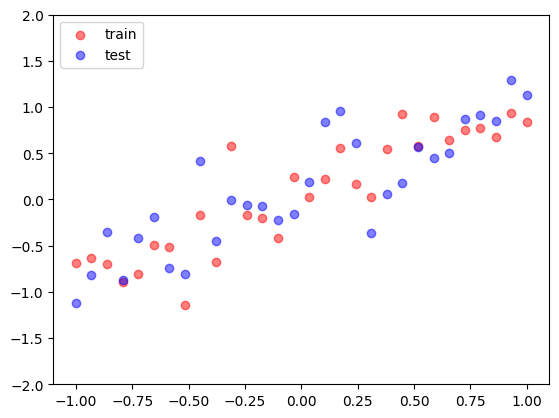

In [26]:
# 绘制训练集和测试集散点图
plt.scatter(x_train, y_train, c='r', alpha=0.5, label='train')
plt.scatter(x_test, y_test, c='b', alpha=0.5, label='test')
plt.legend(loc='upper left')  # 显示图例，并放在左上角
plt.ylim((-2, 2))  # 设置 y 轴显示范围
plt.show()

### 模型定义

In [27]:
# 定义一个可能产生过拟合的神经网络
# 网络结构：输入层(1) → 隐藏层(hidden_size) → 隐藏层(hidden_size) → 输出层(1)
net_overfitting = torch.nn.Sequential(
    torch.nn.Linear(1, hidden_size),               # 全连接层：1 → hidden_size
    torch.nn.ReLU(),                               # ReLU 激活函数

    torch.nn.Linear(hidden_size, hidden_size),     # 第二个全连接层
    torch.nn.ReLU(),                               # ReLU 激活函数

    torch.nn.Linear(hidden_size, 1)                # 输出层：hidden_size → 1
)


# 定义一个加入 Dropout 的神经网络，Dropout 会在训练时随机丢弃部分神经元，降低过拟合风险
net_dropout = torch.nn.Sequential(
    torch.nn.Linear(1, hidden_size),               # 全连接层：1 → hidden_size
    torch.nn.Dropout(0.5),                         # 随机丢弃 50% 的神经元
    torch.nn.ReLU(),                               # ReLU 激活函数

    torch.nn.Linear(hidden_size, hidden_size),     # 第二个全连接层
    torch.nn.Dropout(0.5),                         # 再次随机丢弃 50% 的神经元
    torch.nn.ReLU(),                               # ReLU 激活函数

    torch.nn.Linear(hidden_size, 1)                # 输出层：hidden_size → 1
)

### 模型训练

In [28]:
# 定义两个模型各自的 Adam 优化器，lr=0.01 表示学习率为 0.01
optimizer_overfitting = torch.optim.Adam(net_overfitting.parameters(), lr=0.01)
optimizer_dropout = torch.optim.Adam(net_dropout.parameters(), lr=0.01)

# 定义损失函数，MSELoss：均方误差，常用于回归问题
criterion = nn.MSELoss()

# 分别训练两个模型
for i in range(num_epochs):
    # ===== 普通网络 net_overfitting =====
    pred_overfitting = net_overfitting(x_train)  # 前向传播：根据训练数据得到预测结果
    loss_overfitting = criterion(pred_overfitting, y_train)  # 计算预测值与真实值之间的损失
    optimizer_overfitting.zero_grad()  # 清空上一轮训练保存的梯度
    loss_overfitting.backward()  # 反向传播，计算各参数的梯度
    optimizer_overfitting.step()  # 根据梯度更新模型参数

    # ===== 包含 Dropout 的网络 net_dropout =====
    pred_dropout = net_dropout(x_train)  # 前向传播
    loss_dropout = criterion(pred_dropout, y_train)  # 计算损失
    optimizer_dropout.zero_grad()  # 清空上一轮的梯度
    loss_dropout.backward()  # 反向传播，计算梯度
    optimizer_dropout.step()  # 更新模型参数

### 可视化

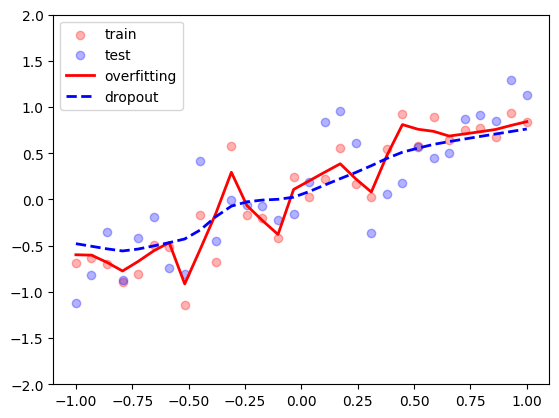

In [29]:
# 将模型切换到评估模式。对 Dropout 网络来说，eval() 会关闭 Dropout，使所有神经元参与预测
net_overfitting.eval()
net_dropout.eval()

# 使用测试集进行预测
test_pred_overfitting = net_overfitting(x_test)
test_pred_dropout = net_dropout(x_test)

# 绘制训练集和测试集的数据点
plt.scatter(x_train, y_train, c='r', alpha=0.3, label='train')
plt.scatter(x_test, y_test, c='b', alpha=0.3, label='test')

# 绘制普通网络的预测曲线
plt.plot(x_test, test_pred_overfitting.data.numpy(), 'r-', lw=2, label='overfitting')
# 绘制 Dropout 网络的预测曲线
plt.plot(x_test, test_pred_dropout.data.numpy(), 'b--', lw=2, label='dropout')

plt.legend(loc='upper left')  # 设置图例位置
plt.ylim((-2, 2))  # 设置 y 轴显示范围
plt.show()